<a href="https://colab.research.google.com/github/islam3ouf/Linear-Algebra-Visualization-With-Python/blob/main/01-Vector-Visualization/notebooks/animated_vector_operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving animation...
Animation saved as 'vector_operations.gif'.


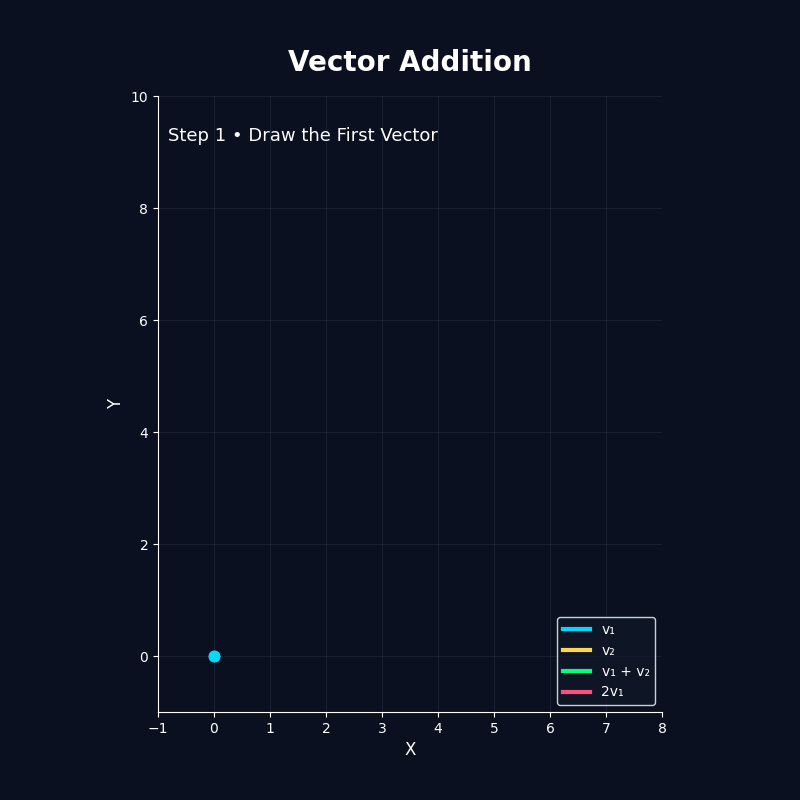

In [ ]:
"""
Vector Operations Visualization
===============================

Animated visualization of:

1. Vector Addition
2. Scalar Multiplication

Author: Islam abo Ouf
"""

from typing import Final

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D


# ============================================================
# VECTOR DATA
# ============================================================

V1: Final[np.ndarray] = np.array([2, 3])
V2: Final[np.ndarray] = np.array([3, 1])

VECTOR_SUM: Final[np.ndarray] = V1 + V2
DOUBLE_V1: Final[np.ndarray] = 2 * V1


# ============================================================
# COLORS
# ============================================================

BACKGROUND_COLOR: Final[str] = "#0B1020"
GRID_COLOR: Final[str] = "#334155"

VECTOR1_COLOR: Final[str] = "#00D9FF"
VECTOR2_COLOR: Final[str] = "#FFD54A"

SUM_COLOR: Final[str] = "#00FF7F"
SCALE_COLOR: Final[str] = "#FF4F81"

TEXT_COLOR: Final[str] = "white"

LEGEND_BACKGROUND: Final[str] = "#101828"


# ============================================================
# FIGURE SETTINGS
# ============================================================

FIGURE_SIZE: Final[tuple[int, int]] = (8, 8)

X_LIMITS: Final[tuple[int, int]] = (-1, 8)
Y_LIMITS: Final[tuple[int, int]] = (-1, 10)

GRID_ALPHA: Final[float] = 0.35
GRID_WIDTH: Final[float] = 0.8

VECTOR_LINE_WIDTH: Final[float] = 3.5

ARROW_HEAD_WIDTH: Final[float] = 0.20
ARROW_HEAD_LENGTH: Final[float] = 0.30


# ============================================================
# ANIMATION TIMELINE
# ============================================================

DRAW_V1_END: Final[int] = 40
DRAW_V2_END: Final[int] = 80
TAIL_TO_HEAD_END: Final[int] = 120
SUM_END: Final[int] = 160

PAUSE_END: Final[int] = 200
FADE_END: Final[int] = 220

SCALAR_START: Final[int] = 260
SCALAR_GROW_END: Final[int] = 320

TOTAL_FRAMES: Final[int] = 360

FRAME_INTERVAL: Final[int] = 40
FPS: Final[int] = 25
REPEAT_DELAY: Final[int] = 1500


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=FIGURE_SIZE,
    facecolor=BACKGROUND_COLOR,
)

ax.set_facecolor(BACKGROUND_COLOR)


# ============================================================
# LEGEND
# ============================================================

LEGEND_HANDLES: Final[list[Line2D]] = [
    Line2D([0], [0], color=VECTOR1_COLOR, lw=3, label="v₁"),
    Line2D([0], [0], color=VECTOR2_COLOR, lw=3, label="v₂"),
    Line2D([0], [0], color=SUM_COLOR, lw=3, label="v₁ + v₂"),
    Line2D([0], [0], color=SCALE_COLOR, lw=3, label="2v₁"),
]


# ============================================================
# AXES STYLE
# ============================================================

def style_axes(ax: plt.Axes) -> None:
    """
    Apply the common visual style to the coordinate system.

    This function configures the coordinate limits,
    aspect ratio, grid, axis appearance, and labels.
    """

    ax.set_xlim(X_LIMITS)
    ax.set_ylim(Y_LIMITS)

    ax.set_aspect("equal")

    ax.grid(
        color=GRID_COLOR,
        linewidth=GRID_WIDTH,
        alpha=GRID_ALPHA,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(TEXT_COLOR)
    ax.spines["bottom"].set_color(TEXT_COLOR)

    ax.tick_params(colors=TEXT_COLOR)

    ax.set_xlabel(
        "X",
        fontsize=12,
        color=TEXT_COLOR,
    )

    ax.set_ylabel(
        "Y",
        fontsize=12,
        color=TEXT_COLOR,
    )


# ============================================================
# FRAME SETUP
# ============================================================

def setup_frame() -> None:
    """
    Prepare a clean animation frame.

    The frame is cleared, styled, and the legend
    is recreated before drawing the next animation step.
    """

    ax.clear()

    ax.set_facecolor(BACKGROUND_COLOR)

    style_axes(ax)

    ax.legend(
        handles=LEGEND_HANDLES,
        loc="lower right",
        facecolor=LEGEND_BACKGROUND,
        edgecolor=TEXT_COLOR,
        fontsize=10,
        labelcolor=TEXT_COLOR,
    )

# ============================================================
# DRAWING HELPERS
# ============================================================

def vector_magnitude(vector: np.ndarray) -> float:
    """
    Compute the Euclidean magnitude of a vector.

    Args:
        vector: A 2D vector.

    Returns:
        The vector magnitude.
    """
    return float(np.linalg.norm(vector))


def vector_coordinates(
    vector: np.ndarray,
    integer_coordinates: bool = False,
) -> str:
    """
    Format a vector as a coordinate string.

    Args:
        vector: Vector to format.
        integer_coordinates: Display integer values if True.

    Returns:
        Coordinate string.
    """
    if integer_coordinates:
        return (
            f"({int(round(vector[0]))}, "
            f"{int(round(vector[1]))})"
        )

    return (
        f"({vector[0]:.1f}, "
        f"{vector[1]:.1f})"
    )


def draw_vector(
    ax: plt.Axes,
    vector: np.ndarray,
    color: str,
    label: str,
    *,
    alpha: float = 1.0,
    integer_coordinates: bool = False,
    show_label: bool = True,
    show_coordinates: bool = True,
    show_magnitude: bool = True,
) -> None:
    """
    Draw a vector from the origin.

    Parameters
    ----------
    ax
        Target axes.

    vector
        Vector to draw.

    color
        Vector color.

    label
        Vector label.

    alpha
        Transparency.

    integer_coordinates
        Display integer coordinates.

    show_label
        Display vector label.

    show_coordinates
        Display vector coordinates.

    show_magnitude
        Display vector magnitude.
    """

    ax.arrow(
        0,
        0,
        vector[0],
        vector[1],
        color=color,
        linewidth=VECTOR_LINE_WIDTH,
        head_width=ARROW_HEAD_WIDTH,
        head_length=ARROW_HEAD_LENGTH,
        length_includes_head=True,
        alpha=alpha,
    )

    ax.scatter(
        vector[0],
        vector[1],
        s=60,
        color=color,
        alpha=alpha,
        zorder=5,
    )

    text_lines = []

    if show_label:
        text_lines.append(label)

    if show_coordinates:
        text_lines.append(
            vector_coordinates(
                vector,
                integer_coordinates,
            )
        )

    if show_magnitude:
        text_lines.append(
            f"|{label}| = {vector_magnitude(vector):.2f}"
        )

    if text_lines:

        ax.text(
            vector[0] + 0.18,
            vector[1] + 0.18,
            "\n".join(text_lines),
            fontsize=11,
            fontweight="bold",
            color=color,
            alpha=alpha,
        )


# ============================================================
# VECTOR ADDITION
# ============================================================

def draw_tail_to_head(ax: plt.Axes) -> None:
    """
    Draw the translated second vector to illustrate
    the Tail-to-Head rule.
    """

    ax.arrow(
        V1[0],
        V1[1],
        V2[0],
        V2[1],
        linestyle="--",
        linewidth=2,
        color=VECTOR2_COLOR,
        alpha=0.55,
        head_width=0.15,
        head_length=0.20,
        length_includes_head=True,
    )


# ============================================================
# TEXT HELPERS
# ============================================================

def draw_title(title: str) -> None:
    """
    Draw the main title.
    """

    ax.set_title(
        title,
        fontsize=20,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=18,
    )


def draw_subtitle(text: str) -> None:
    """
    Draw the animation subtitle.
    """

    ax.text(
        0.02,
        0.95,
        text,
        transform=ax.transAxes,
        fontsize=13,
        color=TEXT_COLOR,
        va="top",
    )


def draw_result(
    expression: str,
) -> None:
    """
    Display the mathematical result
    below the subtitle.
    """

    ax.text(
        0.02,
        0.90,
        expression,
        transform=ax.transAxes,
        fontsize=12,
        color=SUM_COLOR,
        fontweight="bold",
    )

# ============================================================
# ANIMATION STAGES (PART 1)
# ============================================================

def animate_step_1(frame: int) -> None:
    """
    Animate the first vector growing from the origin.
    """

    progress = frame / DRAW_V1_END

    draw_title("Vector Addition")

    draw_subtitle("Step 1 • Draw the First Vector")

    draw_vector(
        ax=ax,
        vector=V1 * progress,
        color=VECTOR1_COLOR,
        label="v₁",
        show_label=False,
        show_coordinates=False,
        show_magnitude=False,
    )

    # Show information only near the end
    if progress >= 0.95:
        draw_vector(
            ax=ax,
            vector=V1,
            color=VECTOR1_COLOR,
            label="v₁",
            integer_coordinates=True,
        )


# ============================================================

def animate_step_2(frame: int) -> None:
    """
    Animate the second vector.
    """

    draw_title("Vector Addition")

    draw_subtitle("Step 2 • Draw the Second Vector")

    draw_vector(
        ax=ax,
        vector=V1,
        color=VECTOR1_COLOR,
        label="v₁",
        integer_coordinates=True,
    )

    progress = (
        frame - DRAW_V1_END
    ) / (
        DRAW_V2_END - DRAW_V1_END
    )

    draw_vector(
        ax=ax,
        vector=V2 * progress,
        color=VECTOR2_COLOR,
        label="v₂",
        show_label=False,
        show_coordinates=False,
        show_magnitude=False,
    )

    if progress >= 0.95:
        draw_vector(
            ax=ax,
            vector=V2,
            color=VECTOR2_COLOR,
            label="v₂",
            integer_coordinates=True,
        )


# ============================================================

def animate_step_3(_: int) -> None:
    """
    Illustrate the Tail-to-Head rule.
    """

    draw_title("Tail-to-Head Rule")

    draw_subtitle(
        "Translate v₂ so that its tail starts at the head of v₁"
    )

    draw_vector(
        ax=ax,
        vector=V1,
        color=VECTOR1_COLOR,
        label="v₁",
        integer_coordinates=True,
    )

    draw_vector(
        ax=ax,
        vector=V2,
        color=VECTOR2_COLOR,
        label="v₂",
        integer_coordinates=True,
    )

    draw_tail_to_head(ax)


# ============================================================

def animate_step_4(frame: int) -> None:
    """
    Animate the resultant vector.
    """

    draw_title("Vector Addition Result")

    draw_subtitle("Resultant Vector")

    draw_vector(
        ax=ax,
        vector=V1,
        color=VECTOR1_COLOR,
        label="v₁",
        integer_coordinates=True,
    )

    draw_vector(
        ax=ax,
        vector=V2,
        color=VECTOR2_COLOR,
        label="v₂",
        integer_coordinates=True,
    )

    draw_tail_to_head(ax)

    progress = (
        frame - TAIL_TO_HEAD_END
    ) / (
        SUM_END - TAIL_TO_HEAD_END
    )

    draw_vector(
        ax=ax,
        vector=VECTOR_SUM * progress,
        color=SUM_COLOR,
        label="v₁ + v₂",
        show_label=False,
        show_coordinates=False,
        show_magnitude=False,
    )

    if progress >= 0.95:

        draw_vector(
            ax=ax,
            vector=VECTOR_SUM,
            color=SUM_COLOR,
            label="v₁ + v₂",
            integer_coordinates=True,
        )

        draw_result("v₁ + v₂ = (5, 4)")


# ============================================================

def animate_step_5(_: int) -> None:
    """
    Pause on the completed vector addition result.
    """

    draw_title("Vector Addition Complete")

    draw_subtitle("Final Result")

    draw_vector(
        ax=ax,
        vector=V1,
        color=VECTOR1_COLOR,
        label="v₁",
        integer_coordinates=True,
    )

    draw_vector(
        ax=ax,
        vector=V2,
        color=VECTOR2_COLOR,
        label="v₂",
        integer_coordinates=True,
    )

    draw_vector(
        ax=ax,
        vector=VECTOR_SUM,
        color=SUM_COLOR,
        label="v₁ + v₂",
        integer_coordinates=True,
    )

    draw_tail_to_head(ax)

    draw_result("v₁ + v₂ = (5, 4)")

# ============================================================
# ANIMATION STAGES (PART 2)
# ============================================================

def animate_step_6(frame: int) -> None:
    """
    Fade out the vector addition scene before
    starting the scalar multiplication animation.
    """

    alpha = 1 - (
        frame - PAUSE_END
    ) / (
        FADE_END - PAUSE_END
    )

    draw_title("Transition")

    draw_subtitle("Preparing the next operation")

    draw_vector(
        ax=ax,
        vector=V1,
        color=VECTOR1_COLOR,
        label="v₁",
        alpha=alpha,
        integer_coordinates=True,
    )

    draw_vector(
        ax=ax,
        vector=V2,
        color=VECTOR2_COLOR,
        label="v₂",
        alpha=alpha,
        integer_coordinates=True,
    )

    draw_vector(
        ax=ax,
        vector=VECTOR_SUM,
        color=SUM_COLOR,
        label="v₁ + v₂",
        alpha=alpha,
        integer_coordinates=True,
    )


# ============================================================

def animate_step_7(_: int) -> None:
    """
    Display the original vector before
    applying scalar multiplication.
    """

    draw_title("Scalar Multiplication")

    draw_subtitle("Original Vector")

    draw_vector(
        ax=ax,
        vector=V1,
        color=VECTOR1_COLOR,
        label="v₁",
        integer_coordinates=True,
    )

    draw_result("Scale the vector by a factor of 2")


# ============================================================

def animate_step_8(frame: int) -> None:
    """
    Animate the vector growing into 2v₁.
    """

    progress = (
        frame - SCALAR_START
    ) / (
        SCALAR_GROW_END - SCALAR_START
    )

    # Smooth animation
    progress = (
        3 * progress**2
        - 2 * progress**3
    )

    current_vector = (
        V1 +
        (DOUBLE_V1 - V1) * progress
    )

    draw_title("Scalar Multiplication")

    draw_subtitle("Scaling the Vector")

    draw_vector(
        ax=ax,
        vector=current_vector,
        color=SCALE_COLOR,
        label="2v₁",
        show_label=False,
        show_coordinates=False,
        show_magnitude=False,
    )

    if progress >= 0.95:

        draw_vector(
            ax=ax,
            vector=DOUBLE_V1,
            color=SCALE_COLOR,
            label="2v₁",
            integer_coordinates=True,
        )

        draw_result("2 × v₁ = (4, 6)")


# ============================================================

def animate_step_9(_: int) -> None:
    """
    Display the completed scalar multiplication result.
    """

    draw_title("Scalar Multiplication Result")

    draw_subtitle("Final Result")

    draw_vector(
        ax=ax,
        vector=DOUBLE_V1,
        color=SCALE_COLOR,
        label="2v₁",
        integer_coordinates=True,
    )

    draw_result("2 × v₁ = (4, 6)")


# ============================================================
# MAIN ANIMATION
# ============================================================

def animate(frame: int) -> None:
    """
    Render a single animation frame.
    """

    setup_frame()

    if frame < DRAW_V1_END:
        animate_step_1(frame)

    elif frame < DRAW_V2_END:
        animate_step_2(frame)

    elif frame < TAIL_TO_HEAD_END:
        animate_step_3(frame)

    elif frame < SUM_END:
        animate_step_4(frame)

    elif frame < PAUSE_END:
        animate_step_5(frame)

    elif frame < FADE_END:
        animate_step_6(frame)

    elif frame < SCALAR_START:
        animate_step_7(frame)

    elif frame < SCALAR_GROW_END:
        animate_step_8(frame)

    else:
        animate_step_9(frame)


# ============================================================
# SAVE ANIMATION
# ============================================================

def save_animation(
    filename: str = "vector_operations.gif",
) -> str:
    """
    Generate and save the animation as a GIF.

    Args:
        filename:
            Output GIF filename.

    Returns:
        Path to the saved GIF.
    """

    animation = FuncAnimation(
        fig=fig,
        func=animate,
        frames=TOTAL_FRAMES,
        interval=FRAME_INTERVAL,
        repeat=True,
        repeat_delay=REPEAT_DELAY,
        blit=False,
    )

    print("Saving animation...")

    animation.save(
        filename,
        writer=PillowWriter(fps=FPS),
    )

    plt.close(fig)

    print(f"Animation saved as '{filename}'.")

    return filename


# ============================================================
# MAIN
# ============================================================

def main() -> None:
    """
    Generate the animation and display it.
    """

    gif_file = save_animation()

    display(
        Image(
            filename=gif_file,
        )
    )


if __name__ == "__main__":
    main()